In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [3]:
# Load the three dataframes
natural_df = pd.read_csv("/scratch1/smaruj/suppressing_CTCFs/results_repeated/natural_ctcfs_with_gc.tsv", sep="\t")
new_df = pd.read_csv("/scratch1/smaruj/suppressing_CTCFs/results_repeated/new_ctcf_df_with_gc.tsv", sep="\t")
preexisting_df = pd.read_csv("/scratch1/smaruj/suppressing_CTCFs/results_repeated/preexisting_ctcf_df_with_gc.tsv", sep="\t")

In [4]:
# Add type labels
natural_df['type'] = 'Natural'
new_df['type'] = 'New (Optimized)'
preexisting_df['type'] = 'Pre-existing'

print("Dataset sizes:")
print(f"Natural CTCFs: {len(natural_df)}")
print(f"New CTCFs: {len(new_df)}")
print(f"Pre-existing CTCFs: {len(preexisting_df)}")

Dataset sizes:
Natural CTCFs: 7560
New CTCFs: 503
Pre-existing CTCFs: 904


In [5]:
# ============= SUMMARY STATISTICS =============
print("\n" + "="*80)
print("GC Content Summary Statistics")
print("="*80)

for name, df in [('Natural', natural_df), ('New (Optimized)', new_df), ('Pre-existing', preexisting_df)]:
    print(f"\n{name} CTCFs (n={len(df)}):")
    print(f"  Core motif:        {df['gc_core'].mean():.3f} ± {df['gc_core'].std():.3f}")
    print(f"  Core + 15bp:       {df['gc_core_plus_15'].mean():.3f} ± {df['gc_core_plus_15'].std():.3f}")
    print(f"  Core + 30bp:       {df['gc_core_plus_30'].mean():.3f} ± {df['gc_core_plus_30'].std():.3f}")
    print(f"  Upstream 15bp:     {df['gc_upstream_15'].mean():.3f} ± {df['gc_upstream_15'].std():.3f}")
    print(f"  Upstream 30bp:     {df['gc_upstream_30'].mean():.3f} ± {df['gc_upstream_30'].std():.3f}")
    print(f"  Downstream 15bp:   {df['gc_downstream_15'].mean():.3f} ± {df['gc_downstream_15'].std():.3f}")
    print(f"  Downstream 30bp:   {df['gc_downstream_30'].mean():.3f} ± {df['gc_downstream_30'].std():.3f}")


GC Content Summary Statistics

Natural CTCFs (n=7560):
  Core motif:        0.598 ± 0.098
  Core + 15bp:       0.536 ± 0.092
  Core + 30bp:       0.519 ± 0.088
  Upstream 15bp:     0.495 ± 0.140
  Upstream 30bp:     0.491 ± 0.118
  Downstream 15bp:   0.500 ± 0.144
  Downstream 30bp:   0.497 ± 0.118

New (Optimized) CTCFs (n=503):
  Core motif:        0.661 ± 0.091
  Core + 15bp:       0.556 ± 0.075
  Core + 30bp:       0.534 ± 0.066
  Upstream 15bp:     0.488 ± 0.125
  Upstream 30bp:     0.500 ± 0.095
  Downstream 15bp:   0.491 ± 0.131
  Downstream 30bp:   0.488 ± 0.099

Pre-existing CTCFs (n=904):
  Core motif:        0.639 ± 0.073
  Core + 15bp:       0.520 ± 0.054
  Core + 30bp:       0.489 ± 0.060
  Upstream 15bp:     0.431 ± 0.111
  Upstream 30bp:     0.454 ± 0.087
  Downstream 15bp:   0.458 ± 0.098
  Downstream 30bp:   0.428 ± 0.115


In [6]:
# ============= STATISTICAL TESTS =============
print("\n" + "="*80)
print("Statistical Comparisons (t-tests)")
print("="*80)

gc_columns = ['gc_core', 'gc_core_plus_15', 'gc_core_plus_30', 
              'gc_upstream_15', 'gc_downstream_15']

for col in gc_columns:
    print(f"\n{col}:")
    
    # Natural vs New
    t_stat, p_val = stats.ttest_ind(natural_df[col].dropna(), new_df[col].dropna())
    print(f"  Natural vs New:         t={t_stat:.3f}, p={p_val:.3e}")
    
    # Natural vs Pre-existing
    t_stat, p_val = stats.ttest_ind(natural_df[col].dropna(), preexisting_df[col].dropna())
    print(f"  Natural vs Pre-existing: t={t_stat:.3f}, p={p_val:.3e}")
    
    # Pre-existing vs New
    t_stat, p_val = stats.ttest_ind(preexisting_df[col].dropna(), new_df[col].dropna())
    print(f"  Pre-existing vs New:     t={t_stat:.3f}, p={p_val:.3e}")


Statistical Comparisons (t-tests)

gc_core:
  Natural vs New:         t=-13.961, p=8.735e-44
  Natural vs Pre-existing: t=-12.122, p=1.524e-33
  Pre-existing vs New:     t=-4.934, p=9.013e-07

gc_core_plus_15:
  Natural vs New:         t=-4.601, p=4.271e-06
  Natural vs Pre-existing: t=5.399, p=6.882e-08
  Pre-existing vs New:     t=-10.397, p=1.912e-24

gc_core_plus_30:
  Natural vs New:         t=-3.711, p=2.074e-04
  Natural vs Pre-existing: t=10.111, p=6.717e-24
  Pre-existing vs New:     t=-13.118, p=3.591e-37

gc_upstream_15:
  Natural vs New:         t=1.076, p=2.820e-01
  Natural vs Pre-existing: t=13.235, p=1.352e-39
  Pre-existing vs New:     t=-8.828, p=3.098e-18

gc_downstream_15:
  Natural vs New:         t=1.413, p=1.578e-01
  Natural vs Pre-existing: t=8.674, p=4.951e-18
  Pre-existing vs New:     t=-5.400, p=7.811e-08


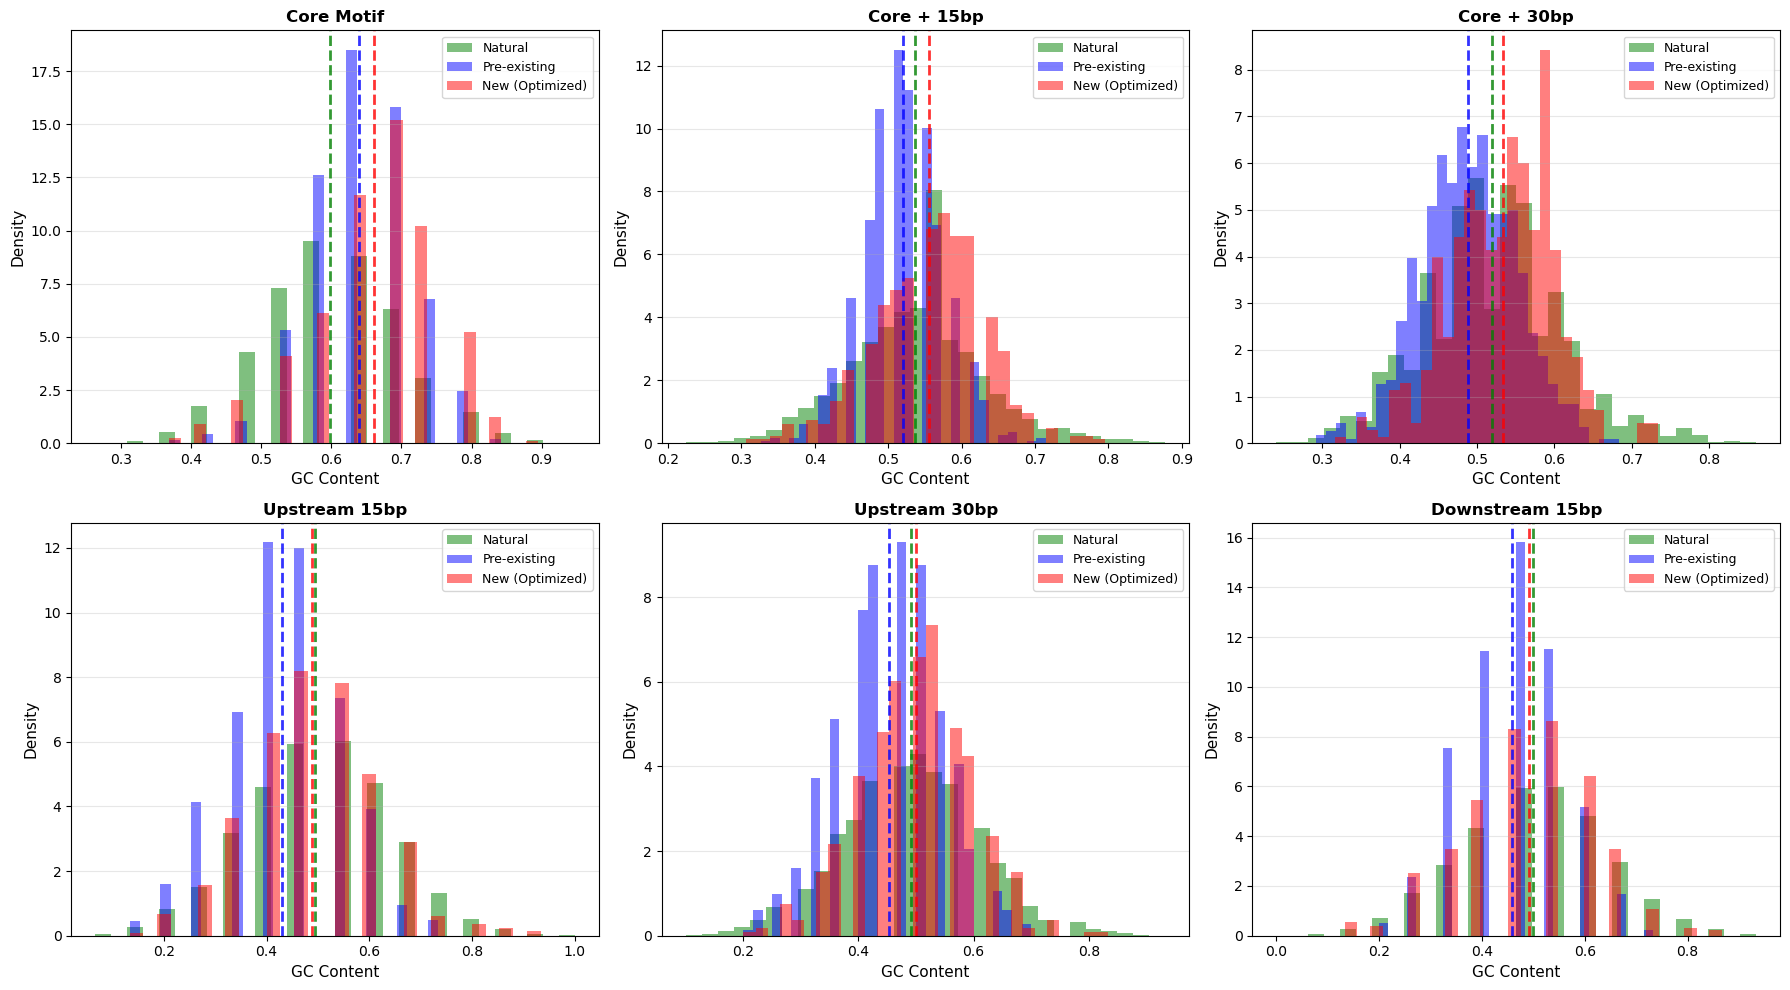

In [7]:
# ============= OVERLAPPING DISTRIBUTIONS =============
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

regions = ['gc_core', 'gc_core_plus_15', 'gc_core_plus_30',
           'gc_upstream_15', 'gc_upstream_30', 'gc_downstream_15']
titles = ['Core Motif', 'Core + 15bp', 'Core + 30bp',
          'Upstream 15bp', 'Upstream 30bp', 'Downstream 15bp']

colors = {'Natural': 'green', 'New (Optimized)': 'red', 'Pre-existing': 'blue'}

for ax, region, title in zip(axes, regions, titles):
    for name, df_subset in [('Natural', natural_df), 
                             ('Pre-existing', preexisting_df),
                             ('New (Optimized)', new_df)]:
        data = df_subset[region].dropna()
        ax.hist(data, bins=30, alpha=0.5, label=name, color=colors[name], density=True)
        
        # Add mean line
        mean_val = data.mean()
        ax.axvline(mean_val, color=colors[name], linestyle='--', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('GC Content', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('/scratch1/smaruj/suppressing_CTCFs/gc_content_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

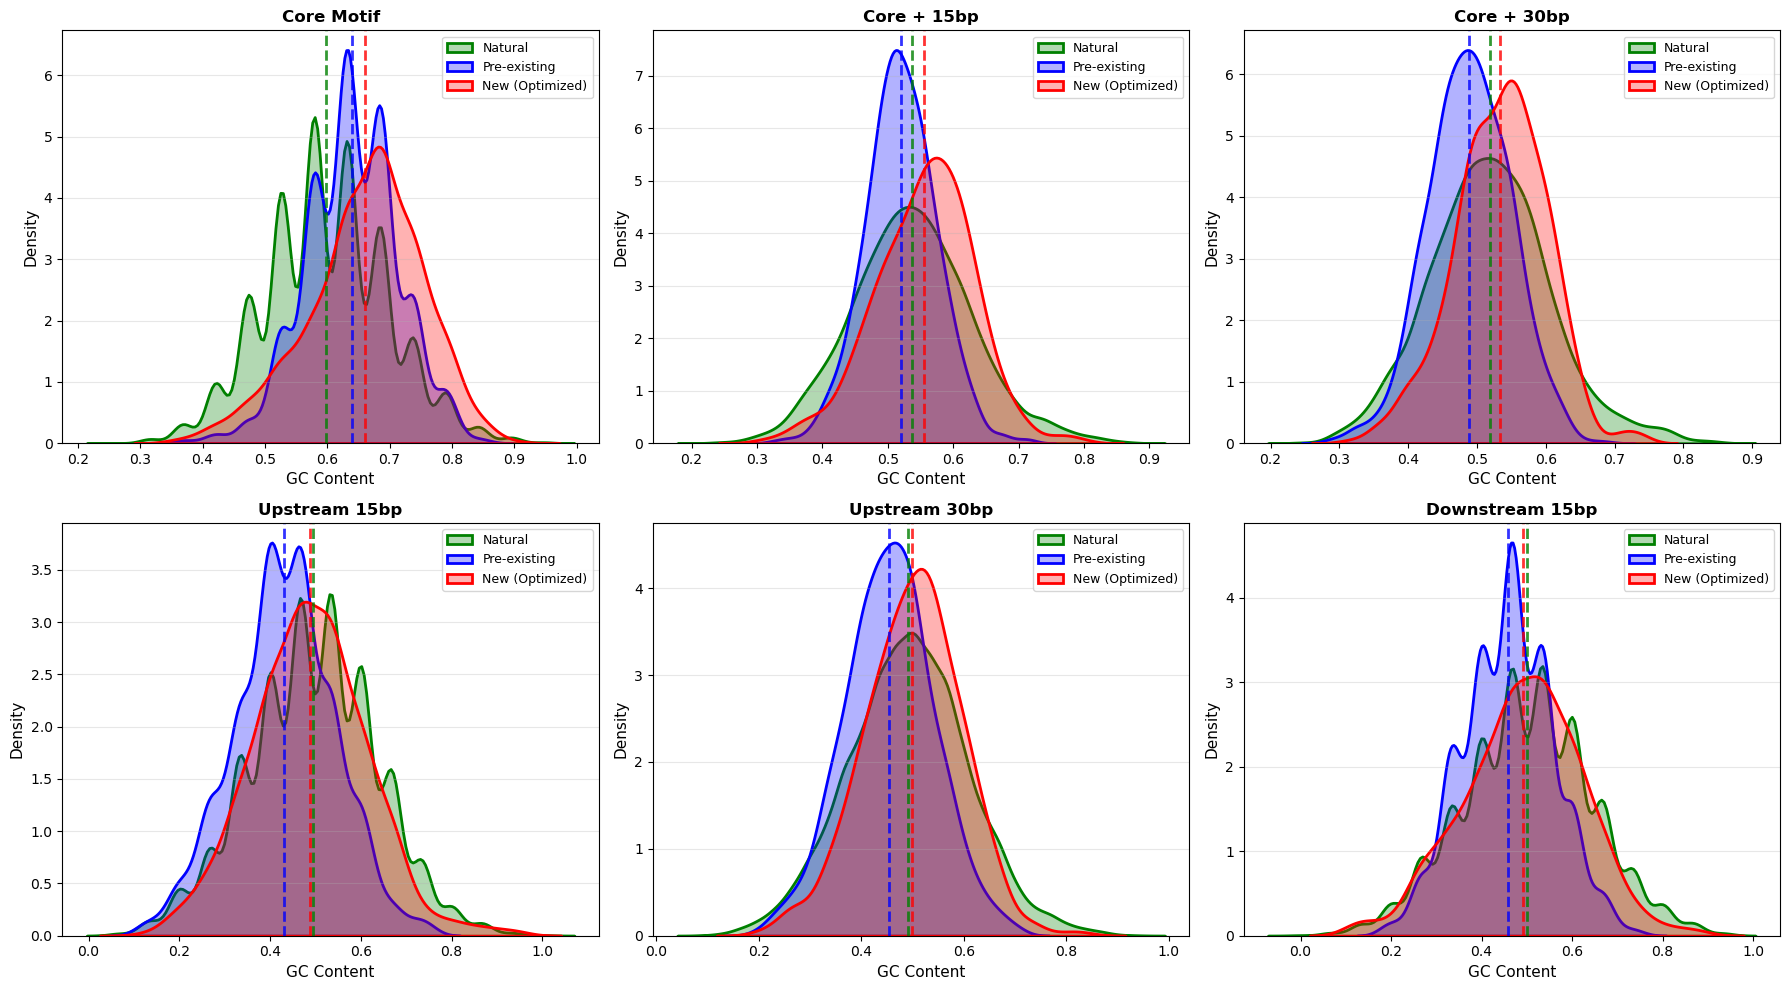

In [8]:
# ============= ALTERNATIVE: KDE PLOTS (SMOOTHER) =============
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, region, title in zip(axes, regions, titles):
    for name, df_subset in [('Natural', natural_df), 
                             ('Pre-existing', preexisting_df),
                             ('New (Optimized)', new_df)]:
        data = df_subset[region].dropna()
        sns.kdeplot(data=data, ax=ax, label=name, color=colors[name], linewidth=2, fill=True, alpha=0.3)
        
        # Add mean line
        mean_val = data.mean()
        ax.axvline(mean_val, color=colors[name], linestyle='--', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('GC Content', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('/scratch1/smaruj/suppressing_CTCFs/gc_content_kde.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/SLURM_2541183/ipykernel_3509911/2638543879.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Natural', 'Pre-existing', 'New'],
/tmp/SLURM_2541183/ipykernel_3509911/2638543879.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Natural', 'Pre-existing', 'New'],
/tmp/SLURM_2541183/ipykernel_3509911/2638543879.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Natural', 'Pre-existing', 'New'],


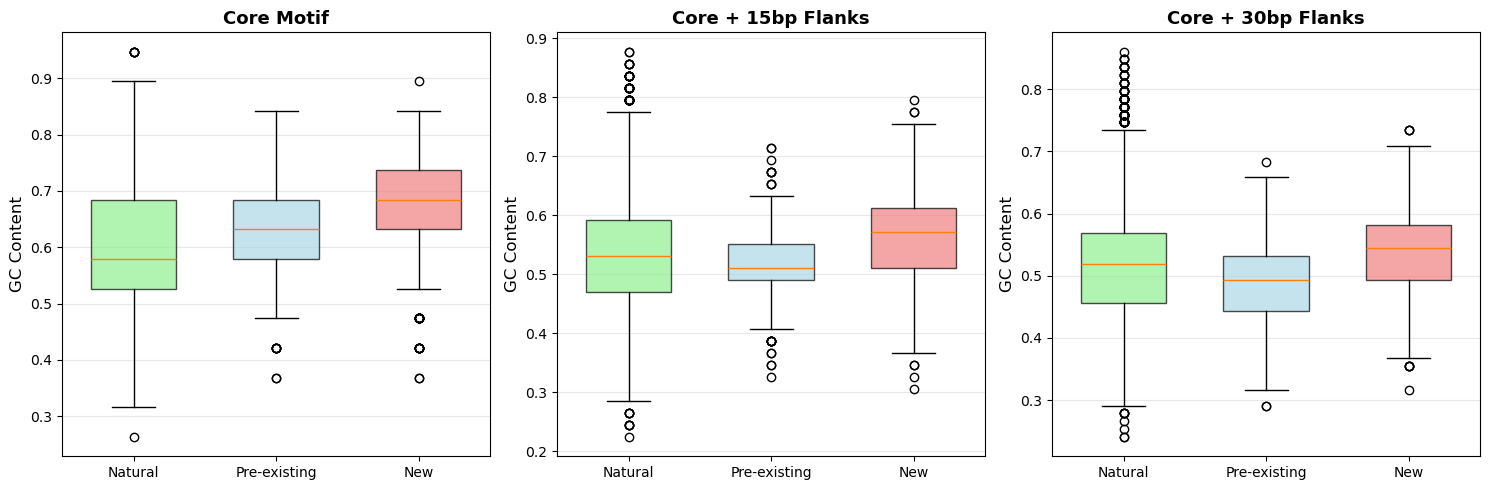

In [9]:
# ============= BOXPLOT COMPARISON =============
# Combine all data
combined_df = pd.concat([natural_df, preexisting_df, new_df], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

regions_to_plot = ['gc_core', 'gc_core_plus_15', 'gc_core_plus_30']
titles_box = ['Core Motif', 'Core + 15bp Flanks', 'Core + 30bp Flanks']

for ax, region, title in zip(axes, regions_to_plot, titles_box):
    data_to_plot = [
        combined_df[combined_df['type'] == 'Natural'][region].dropna(),
        combined_df[combined_df['type'] == 'Pre-existing'][region].dropna(),
        combined_df[combined_df['type'] == 'New (Optimized)'][region].dropna()
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['Natural', 'Pre-existing', 'New'], 
                    patch_artist=True, widths=0.6)
    
    box_colors = ['lightgreen', 'lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('GC Content', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('/scratch1/smaruj/suppressing_CTCFs/gc_content_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()